# National Job Market Predictor (Model-Ready CSV)

This notebook uses the prebuilt `annual_wage_model_data_2010_2024.csv` file to train and evaluate the same occupation-level forecasting model from the original notebook. The raw BLS/OEWS file discovery, cleaning, schema standardization, and target-building steps are skipped because they have already been saved in the CSV.

**Model choice:** RNN model is used as the main model. It predicts each occupation's next-year employment and annual mean wage from the current year's occupation, employment, annual wage, and SOC-code features.

## Report Summary

### Data Used

The notebook reads the model-ready `annual_wage_model_data_2010_2024.csv` file. That CSV already contains the cleaned annual-wage panel, one-year-ahead targets, SOC-code features, log transforms, employment share, and train/holdout split labels.

### Preprocessing Skipped

The original notebook's raw-file preprocessing is not repeated here. This version does not discover BLS/OEWS source files, standardize raw column names, remove hourly wage fields, filter occupation groups, or create lagged targets from scratch.

### Modeling

The model predicts next-year `TOT_EMP` and next-year annual mean wage `A_MEAN`. It uses a `RandomForestRegressor`, which averages many decision trees so the final prediction is less dependent on any single tree. The trees learn nonlinear relationships between prior-year employment, annual wage levels, wage percentiles, SOC-code groupings, occupation title/code, and year.

### Validation

The notebook uses the same time-aware split. It trains on transitions whose target year is 2022 or earlier, then tests on 2023 and 2024 target years. This avoids training directly on the outcomes being scored.

In [9]:
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "annual_wage_model_data_2010_2024.csv"

In [10]:
model_data = pd.read_csv(DATA_PATH)
model_data = model_data.rename(columns={"TARGET_YEAR": "NEXT_YEAR"})

numeric_columns = [
    "YEAR",
    "NEXT_YEAR",
    "TOT_EMP",
    "EMP_PRSE",
    "A_MEAN",
    "MEAN_PRSE",
    "A_PCT10",
    "A_PCT25",
    "A_MEDIAN",
    "A_PCT75",
    "A_PCT90",
    "LOG_TOT_EMP",
    "LOG_A_MEAN",
    "EMPLOYMENT_SHARE",
    "NEXT_TOT_EMP",
    "NEXT_A_MEAN",
    "TARGET_LOG_TOT_EMP",
    "TARGET_LOG_A_MEAN",
]
for column in numeric_columns:
    if column in model_data.columns:
        model_data[column] = pd.to_numeric(model_data[column], errors="coerce")

model_data["YEAR"] = model_data["YEAR"].astype(int)
model_data["NEXT_YEAR"] = model_data["NEXT_YEAR"].astype(int)

# Rebuild a panel-shaped table for the unchanged final forecast section.
# The model-ready CSV contains completed transitions, so the latest feature year
# is reconstructed from the latest target values saved in the CSV.
panel = model_data.copy()
latest_target_year = int(model_data["NEXT_YEAR"].max())
latest_target_features = model_data[model_data["NEXT_YEAR"].eq(latest_target_year)].copy()
latest_target_features["YEAR"] = latest_target_features["NEXT_YEAR"]
latest_target_features["TOT_EMP"] = latest_target_features["NEXT_TOT_EMP"]
latest_target_features["A_MEAN"] = latest_target_features["NEXT_A_MEAN"]
latest_target_features["LOG_TOT_EMP"] = latest_target_features["TARGET_LOG_TOT_EMP"]
latest_target_features["LOG_A_MEAN"] = latest_target_features["TARGET_LOG_A_MEAN"]
latest_target_features["EMPLOYMENT_SHARE"] = (
    latest_target_features["TOT_EMP"] / latest_target_features["TOT_EMP"].sum()
)

for unavailable_column in ["EMP_PRSE", "MEAN_PRSE", "A_PCT10", "A_PCT25", "A_MEDIAN", "A_PCT75", "A_PCT90"]:
    if unavailable_column in latest_target_features.columns:
        latest_target_features[unavailable_column] = np.nan

panel = (
    pd.concat([panel, latest_target_features], ignore_index=True)
    .sort_values(["OCC_CODE", "YEAR"])
    .drop_duplicates(["OCC_CODE", "YEAR"], keep="last")
    .reset_index(drop=True)
)

print(f"Loaded {model_data.shape[0]} model rows from {DATA_PATH.name}")
print("Training/holdout target years:", sorted(model_data["NEXT_YEAR"].unique()))
print("Panel feature years:", sorted(panel["YEAR"].unique()))
model_data.head()

Loaded 11149 model rows from annual_wage_model_data_2010_2024.csv
Training/holdout target years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Panel feature years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,YEAR,NEXT_YEAR,OCC_CODE,OCC_TITLE,SOURCE_FILE,OCC_MAJOR,OCC_MINOR,TOT_EMP,EMP_PRSE,A_MEAN,MEAN_PRSE,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,LOG_TOT_EMP,LOG_A_MEAN,EMPLOYMENT_SHARE,NEXT_TOT_EMP,NEXT_A_MEAN,TARGET_LOG_TOT_EMP,TARGET_LOG_A_MEAN,DATA_SPLIT
0,2010,2011,11-1011,Chief Executives,converted_csv/oesm10nat/national_M2010_dl__nat...,11,11-10,273500.0,0.5,173350.0,0.3,75160.0,107990.0,165080.0,NaN,NaN,12.519061,12.063074,0.002152,267370,176550,12.496392,12.081365,train_through_2022
1,2011,2012,11-1011,Chief Executives,oesm11nat/national_M2011_dl.csv,11,11-10,267370.0,0.5,176550.0,0.4,75860.0,109320.0,166910.0,NaN,NaN,12.496392,12.081365,0.002084,255940,176840,12.452702,12.083006,train_through_2022
2,2012,2013,11-1011,Chief Executives,converted_csv/oesm12nat/national_M2012_dl__nat...,11,11-10,255940.0,0.6,176840.0,0.3,76220.0,109940.0,168140.0,NaN,NaN,12.452702,12.083006,0.001964,248760,178400,12.424248,12.091789,train_through_2022
3,2013,2014,11-1011,Chief Executives,converted_csv/oesm13nat/national_M2013_dl__nat...,11,11-10,248760.0,0.6,178400.0,0.3,75030.0,110610.0,171610.0,NaN,NaN,12.424248,12.091789,0.001876,246240,180700,12.414066,12.104599,train_through_2022
4,2014,2015,11-1011,Chief Executives,converted_csv/oesm14nat/national_M2014_dl__nat...,11,11-10,246240.0,0.8,180700.0,0.4,72750.0,110760.0,173320.0,NaN,NaN,12.414066,12.104599,0.001822,238940,185850,12.383972,12.132701,train_through_2022


In [11]:
FEATURE_COLUMNS = [
    "YEAR",
    "OCC_CODE",
    "OCC_TITLE",
    "OCC_MAJOR",
    "OCC_MINOR",
    "TOT_EMP",
    "EMP_PRSE",
    "A_MEAN",
    "MEAN_PRSE",
    "A_PCT10",
    "A_PCT25",
    "A_MEDIAN",
    "A_PCT75",
    "A_PCT90",
    "LOG_TOT_EMP",
    "LOG_A_MEAN",
    "EMPLOYMENT_SHARE",
]
TARGET_COLUMNS = ["TARGET_LOG_TOT_EMP", "TARGET_LOG_A_MEAN"]
TRAIN_TARGET_END_YEAR = 2022
TEST_TARGET_YEARS = [2023, 2024]

available_features = [column for column in FEATURE_COLUMNS if column in model_data.columns]
categorical_features = ["OCC_CODE", "OCC_TITLE", "OCC_MAJOR", "OCC_MINOR"]
numeric_features = [column for column in available_features if column not in categorical_features]

train_data = model_data[model_data["NEXT_YEAR"].le(TRAIN_TARGET_END_YEAR)].copy()
test_data = model_data[model_data["NEXT_YEAR"].isin(TEST_TARGET_YEARS)].copy()

print(f"Training target years: {int(train_data['NEXT_YEAR'].min())}-{int(train_data['NEXT_YEAR'].max())}")
print("Testing target years:", sorted(test_data["NEXT_YEAR"].astype(int).unique()))
print("Train rows:", train_data.shape[0], "Test rows:", test_data.shape[0])

Training target years: 2011-2022
Testing target years: [np.int64(2023), np.int64(2024)]
Train rows: 9498 Test rows: 1651


In [12]:
# --- Definitions copied from csv-model-03 to ensure dependencies are met ---
import pandas as pd
import numpy as np # Ensure numpy is available for operations like np.nan, np.expm1
from sklearn.impute import SimpleImputer # Needed for SimpleImputer
from sklearn.preprocessing import StandardScaler # Needed for StandardScaler
import torch # Needed for torch operations
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

model_data = pd.read_csv(DATA_PATH)
model_data = model_data.rename(columns={"TARGET_YEAR": "NEXT_YEAR"})

numeric_columns_from_03 = [
    "YEAR", "NEXT_YEAR", "TOT_EMP", "EMP_PRSE", "A_MEAN", "MEAN_PRSE",
    "A_PCT10", "A_PCT25", "A_MEDIAN", "A_PCT75", "A_PCT90", "LOG_TOT_EMP",
    "LOG_A_MEAN", "EMPLOYMENT_SHARE", "NEXT_TOT_EMP", "NEXT_A_MEAN",
    "TARGET_LOG_TOT_EMP", "TARGET_LOG_A_MEAN",
]
for column in numeric_columns_from_03:
    if column in model_data.columns:
        model_data[column] = pd.to_numeric(model_data[column], errors="coerce")

model_data["YEAR"] = model_data["YEAR"].astype(int)
model_data["NEXT_YEAR"] = model_data["NEXT_YEAR"].astype(int)

panel = model_data.copy()
latest_target_year = int(model_data["NEXT_YEAR"].max())
latest_target_features = model_data[model_data["NEXT_YEAR"].eq(latest_target_year)].copy()
latest_target_features["YEAR"] = latest_target_features["NEXT_YEAR"]
latest_target_features["TOT_EMP"] = latest_target_features["NEXT_TOT_EMP"]
latest_target_features["A_MEAN"] = latest_target_features["NEXT_A_MEAN"]
latest_target_features["LOG_TOT_EMP"] = latest_target_features["TARGET_LOG_TOT_EMP"]
latest_target_features["LOG_A_MEAN"] = latest_target_features["TARGET_LOG_A_MEAN"]
latest_target_features["EMPLOYMENT_SHARE"] = (
    latest_target_features["TOT_EMP"] / latest_target_features["TOT_EMP"].sum()
)

for unavailable_column in ["EMP_PRSE", "MEAN_PRSE", "A_PCT10", "A_PCT25", "A_MEDIAN", "A_PCT75", "A_PCT90"]:
    if unavailable_column in latest_target_features.columns:
        latest_target_features[unavailable_column] = np.nan

panel = (
    pd.concat([panel, latest_target_features], ignore_index=True)
    .sort_values(["OCC_CODE", "YEAR"])
    .drop_duplicates(["OCC_CODE", "YEAR"], keep="last")
    .reset_index(drop=True)
)
# --- End definitions copied from csv-model-03 ---


# --- Definitions copied from csv-model-04 to ensure dependencies are met ---
FEATURE_COLUMNS = [
    "YEAR", "OCC_CODE", "OCC_TITLE", "OCC_MAJOR", "OCC_MINOR", "TOT_EMP",
    "EMP_PRSE", "A_MEAN", "MEAN_PRSE", "A_PCT10", "A_PCT25", "A_MEDIAN",
    "A_PCT75", "A_PCT90", "LOG_TOT_EMP", "LOG_A_MEAN", "EMPLOYMENT_SHARE",
]
TARGET_COLUMNS = ["TARGET_LOG_TOT_EMP", "TARGET_LOG_A_MEAN"]
TRAIN_TARGET_END_YEAR = 2022
TEST_TARGET_YEARS = [2023, 2024]

available_features = [column for column in FEATURE_COLUMNS if column in model_data.columns]
categorical_features = ["OCC_CODE", "OCC_TITLE", "OCC_MAJOR", "OCC_MINOR"]
numeric_features = [column for column in available_features if column not in categorical_features]
# --- End definitions copied from csv-model-04 ---


SEQUENCE_LENGTH = 3
RNN_FEATURE_COLUMNS = numeric_features
BATCH_SIZE = 32
EPOCHS = 20

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

panel_scaled = panel.copy()
panel_scaled[RNN_FEATURE_COLUMNS] = imputer.fit_transform(panel[RNN_FEATURE_COLUMNS])
panel_scaled[RNN_FEATURE_COLUMNS] = scaler.fit_transform(panel_scaled[RNN_FEATURE_COLUMNS])

def create_sequences(data, feature_cols, target_cols, sequence_length):
    X, y, metadata_indices = [], [], []
    for occ_code, group in data.groupby("OCC_CODE"):
        if len(group) >= sequence_length + 1:
            for i in range(len(group) - sequence_length):
                X.append(group.iloc[i:i+sequence_length][feature_cols].values)
                y.append(group.iloc[i+sequence_length][target_cols].values)
                metadata_indices.append(group.iloc[i+sequence_length].name)
    return np.array(X), np.array(y), metadata_indices

X, y, meta_indices = create_sequences(panel_scaled, RNN_FEATURE_COLUMNS, TARGET_COLUMNS, SEQUENCE_LENGTH)
meta = panel.loc[meta_indices].reset_index(drop=True)

target_imputer = SimpleImputer(strategy="median")
y = target_imputer.fit_transform(y)

train_indices = meta[meta["NEXT_YEAR"] <= TRAIN_TARGET_END_YEAR].index.to_list()
test_indices = meta[meta["NEXT_YEAR"].isin(TEST_TARGET_YEARS)].index.to_list()

X_train, y_train = torch.tensor(X[train_indices], dtype=torch.float32), torch.tensor(y[train_indices], dtype=torch.float32)
X_test, y_test = torch.tensor(X[test_indices], dtype=torch.float32), torch.tensor(y[test_indices], dtype=torch.float32)
meta_test = meta.loc[test_indices]

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel(input_size=X_train.shape[2], hidden_size=50, num_layers=1, output_size=y_train.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loss_history = [] # Initialize list to store loss

for epoch in range(EPOCHS):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    loss_history.append(loss.item()) # Store the loss at the end of each epoch

model.eval()
with torch.no_grad():
    predicted_log = model(X_test).numpy()

predictions = pd.DataFrame(
    {
        "YEAR": meta_test["YEAR"].to_numpy(),
        "TARGET_YEAR": meta_test["NEXT_YEAR"].to_numpy().astype(int),
        "OCC_CODE": meta_test["OCC_CODE"].to_numpy(),
        "OCC_TITLE": meta_test["OCC_TITLE"].to_numpy(),
        "ACTUAL_TOT_EMP": meta_test["NEXT_TOT_EMP"].to_numpy(),
        "PREDICTED_TOT_EMP": np.expm1(predicted_log[:, 0]),
        "ACTUAL_A_MEAN": meta_test["NEXT_A_MEAN"].to_numpy(),
        "PREDICTED_A_MEAN": np.expm1(predicted_log[:, 1]),
    }
)
predictions.head()

,YEAR,TARGET_YEAR,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,ACTUAL_A_MEAN,PREDICTED_A_MEAN
0,2022,2023,11-1011,Chief Executives,211230,1.942308e+05,258900,211434.421875
1,2023,2024,11-1011,Chief Executives,211850,1.903973e+05,262930,215837.500000
2,2024,2024,11-1011,Chief Executives,211850,1.704402e+05,262930,207899.890625
3,2022,2023,11-1021,General and Operations Managers,3507810,2.549973e+06,129330,119292.429688
4,2023,2024,11-1021,General and Operations Managers,3584420,2.602574e+06,133120,110360.851562


In [13]:
def regression_report(actual: pd.Series, predicted: pd.Series) -> dict[str, float]:
    actual = pd.Series(actual, dtype="float64")
    predicted = pd.Series(predicted, dtype="float64")
    wape = actual.sub(predicted).abs().sum() / actual.abs().sum()
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "WAPE": wape,
        "ACCURACY_PERCENT": (1 - wape) * 100,
        "R2": r2_score(actual, predicted),
    }


def make_metrics(data: pd.DataFrame, label: str) -> list[dict[str, float | str | int]]:
    return [
        {"split": label, "target": "TOT_EMP", **regression_report(data["ACTUAL_TOT_EMP"], data["PREDICTED_TOT_EMP"])},
        {"split": label, "target": "A_MEAN", **regression_report(data["ACTUAL_A_MEAN"], data["PREDICTED_A_MEAN"])},
    ]


metrics = pd.DataFrame(make_metrics(predictions, "2023-2024 holdout"))
metrics_by_year = pd.DataFrame(
    row
    for target_year, year_predictions in predictions.groupby("TARGET_YEAR")
    for row in make_metrics(year_predictions, int(target_year))
)

display(metrics)
metrics_by_year

,split,target,MAE,RMSE,WAPE,ACCURACY_PERCENT,R2
0,2023-2024 holdout,TOT_EMP,24362.448406,96191.289828,0.129061,87.093885,0.954291
1,2023-2024 holdout,A_MEAN,7596.580072,17877.634722,0.101799,89.820054,0.833883


,split,target,MAE,RMSE,WAPE,ACCURACY_PERCENT,R2
0,2023,TOT_EMP,23370.953076,91017.250903,0.123825,87.617497,0.958990
1,2023,A_MEAN,5803.716051,13064.731803,0.081281,91.871870,0.888156
2,2024,TOT_EMP,24840.202726,98587.514875,0.131584,86.841631,0.952034
3,2024,A_MEAN,8460.475752,19783.036316,0.111067,88.893315,0.814369


### Model Evaluation

The model is evaluated on held-out 2023 and 2024 target years, which were not used for training. The table above summarizes error with `MAE`, `RMSE`, `WAPE`, accuracy percent, and `R2`.

For a class presentation, the most useful visuals are actual-versus-predicted plots, residual distributions, and year-by-year metric comparisons. Together, they show whether predictions follow the true values, whether errors are centered near zero, and whether performance is stable across the holdout years.

The final plots below focus on the `TOT_EMP` loss requested here, calculated as:

$$
\text{loss} = \hat{y}_{TOT\_EMP} - y_{TOT\_EMP}
$$

Positive values mean the model over-predicted employment; negative values mean it under-predicted employment.

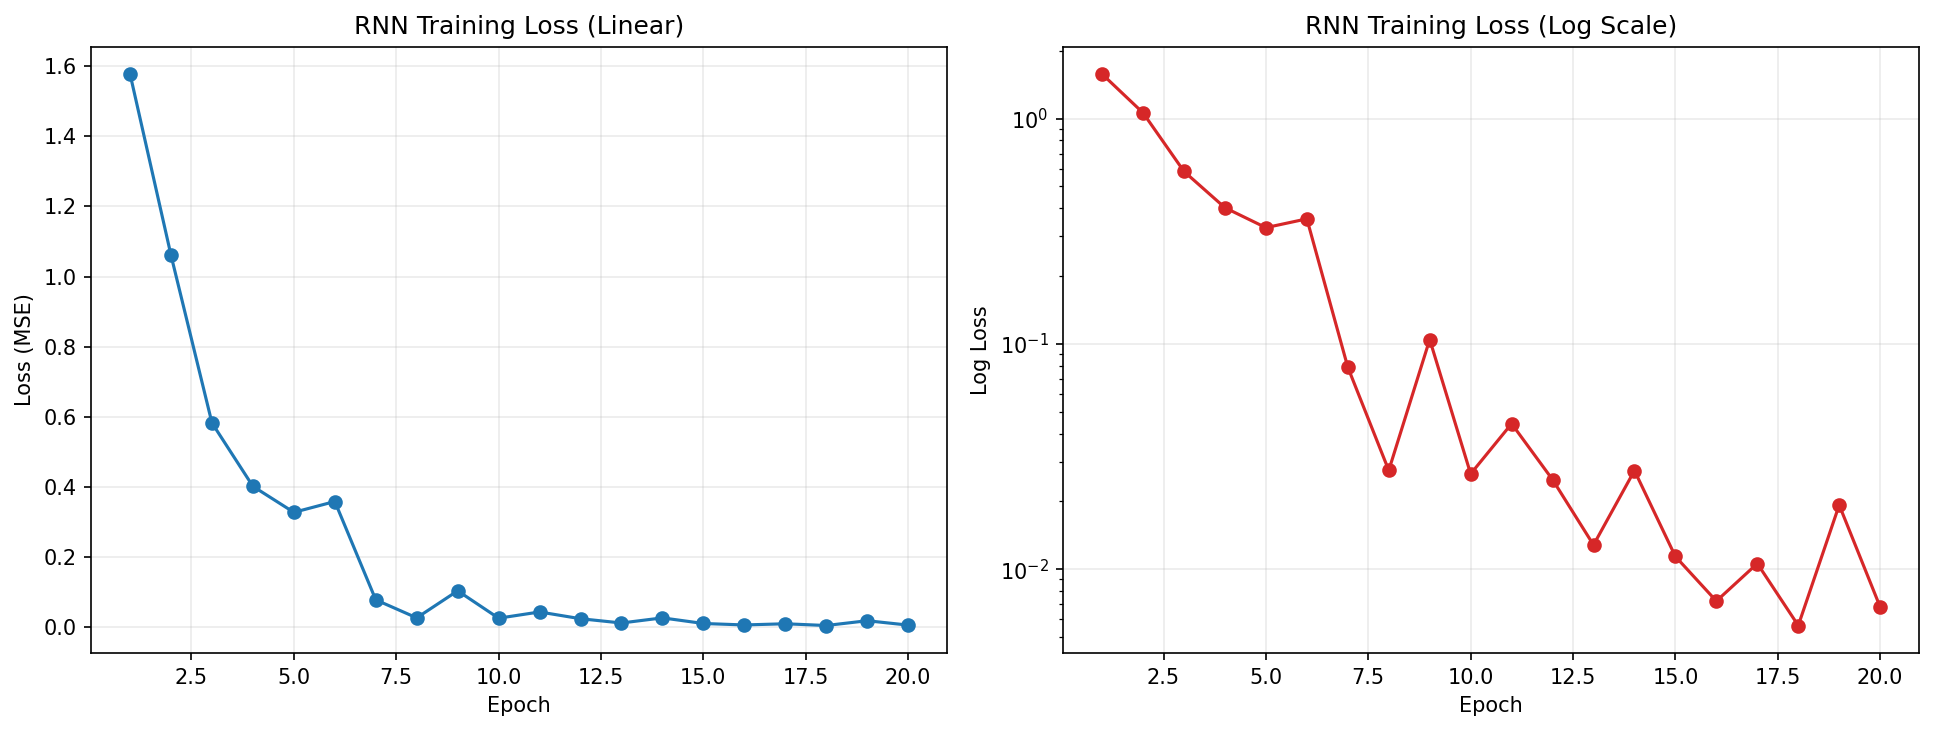

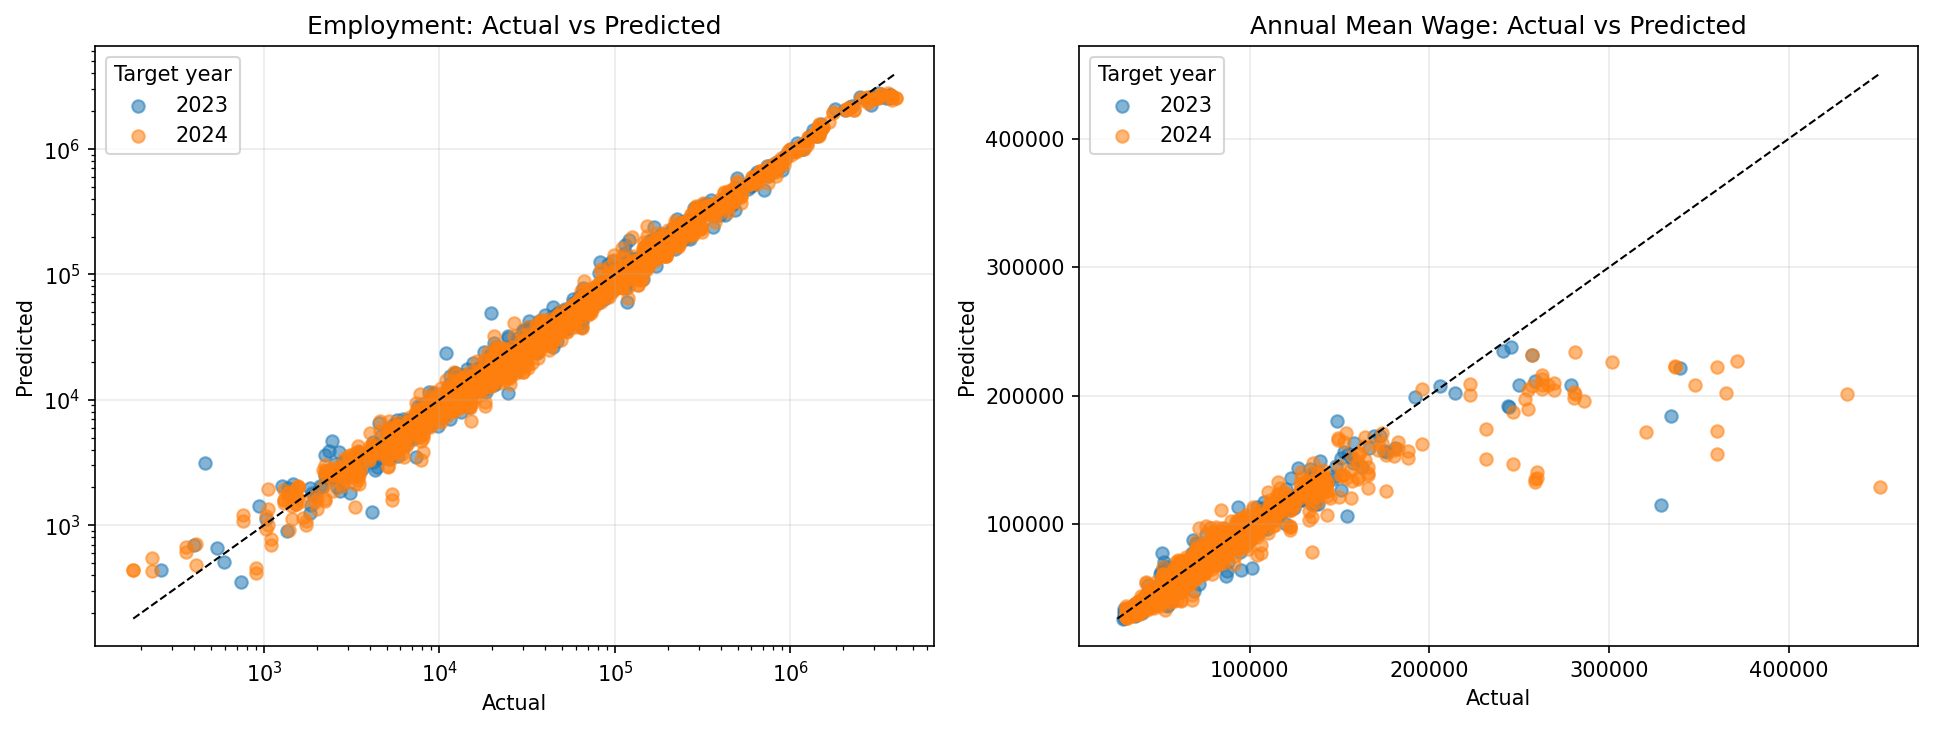

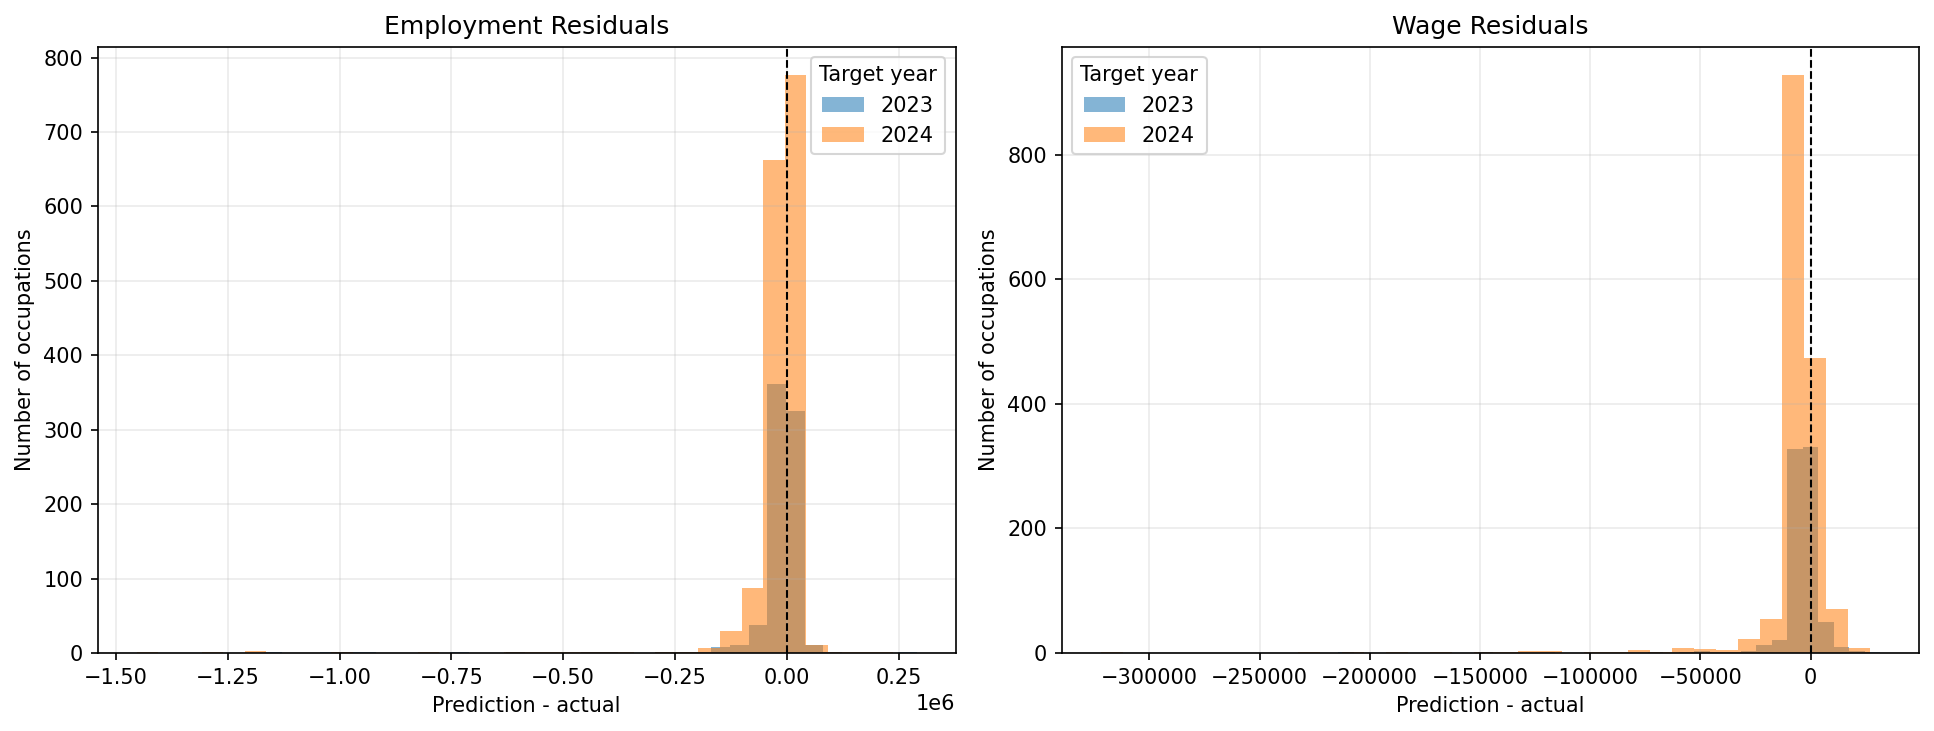

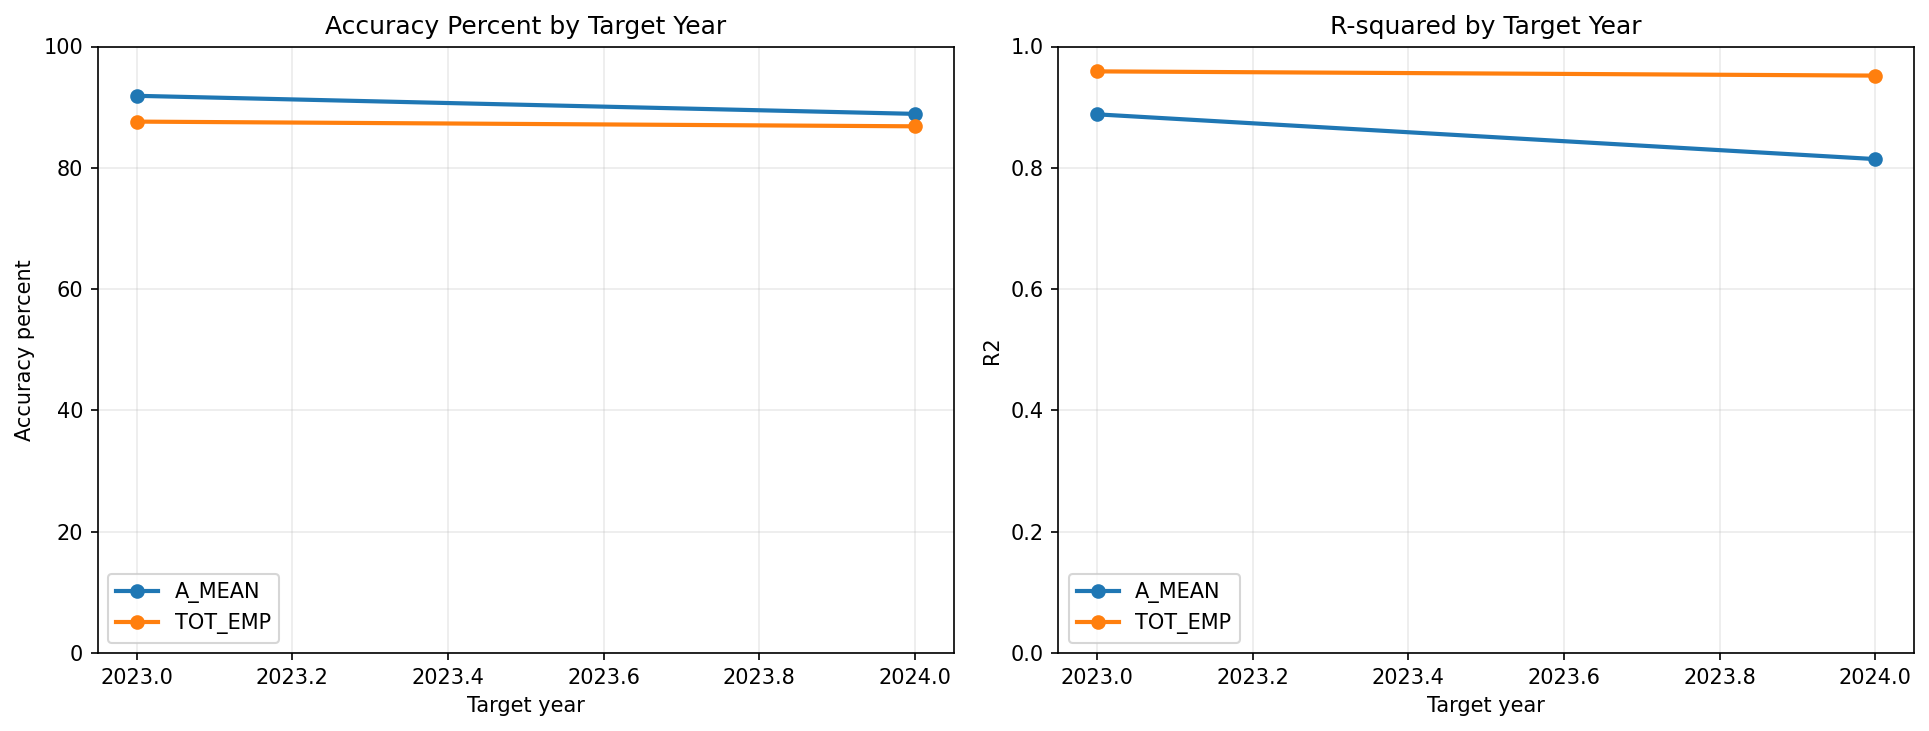

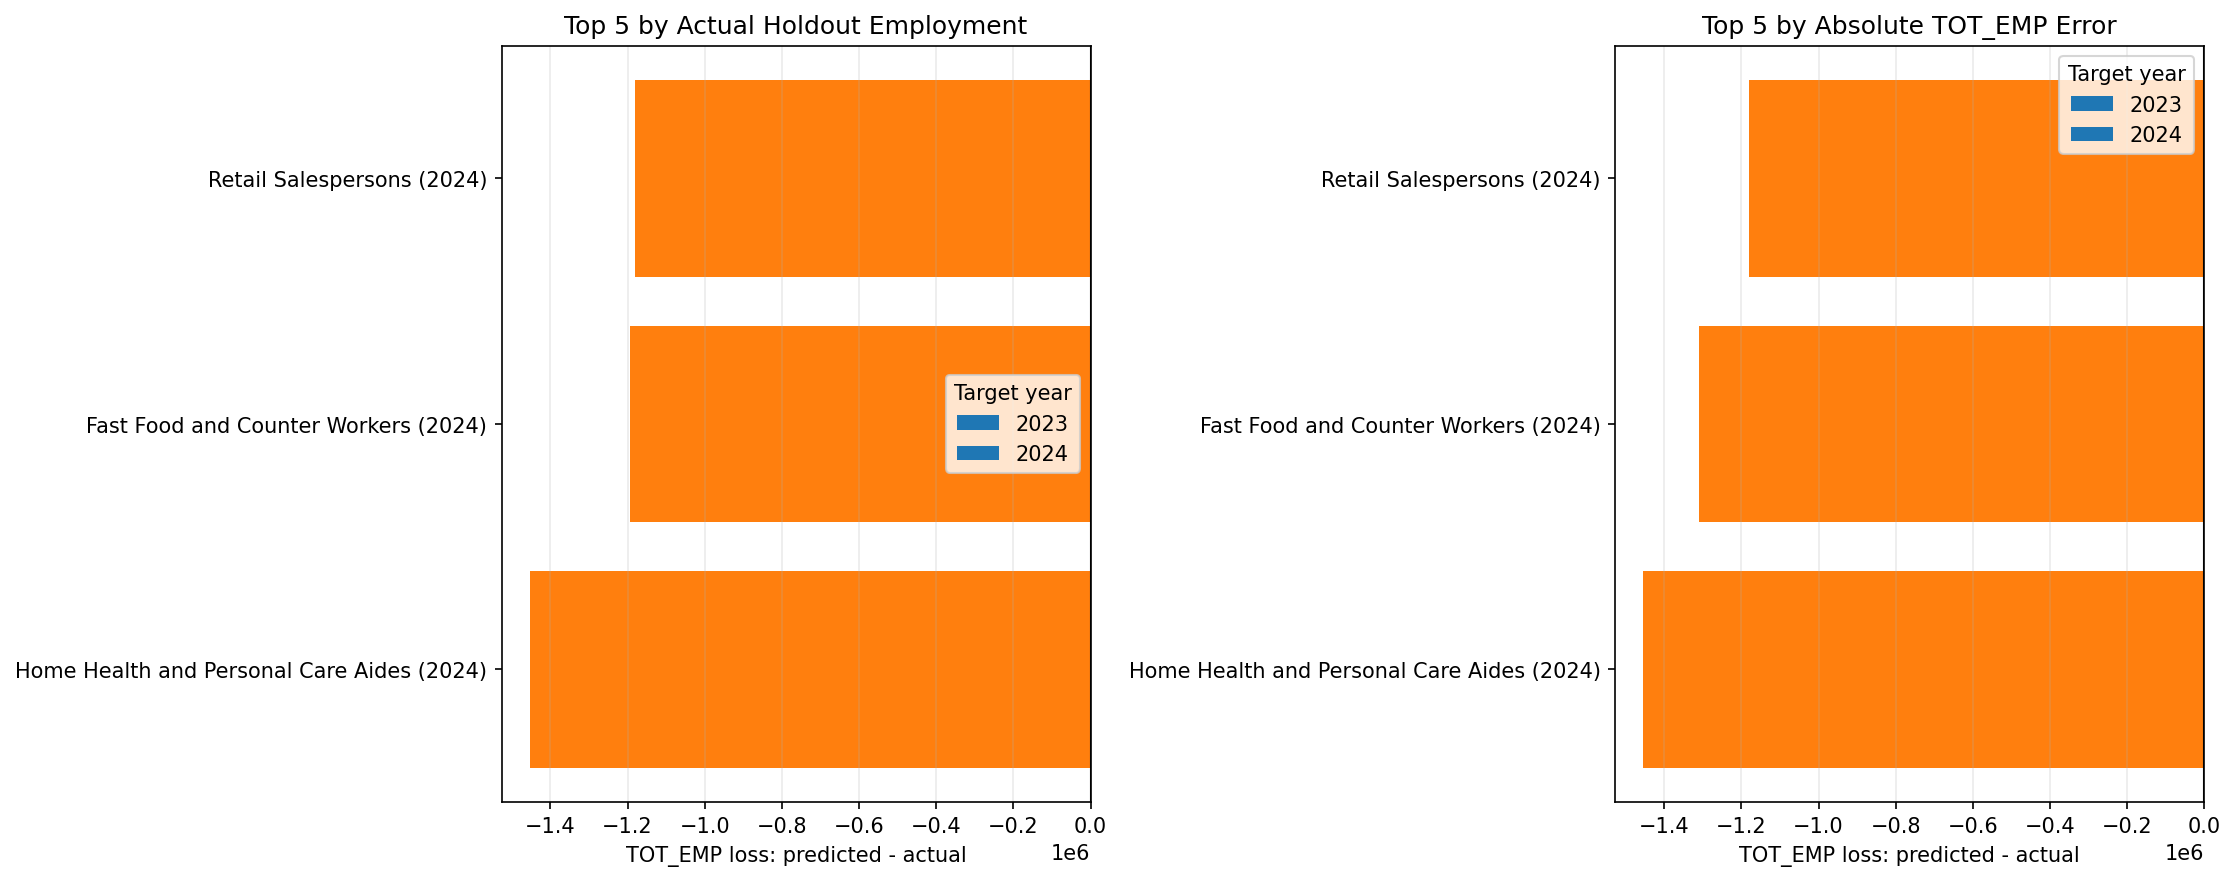

,Epoch,Loss (MSE)
0,1,1.577278
1,10,0.026487
2,20,0.006796


,TARGET_YEAR,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,TOT_EMP_LOSS
1026,2024,31-1120,Home Health and Personal Care Aides,3988140,2534323.25,-1453816.75
1027,2024,31-1120,Home Health and Personal Care Aides,3988140,2542571.25,-1445568.75
1334,2024,41-2031,Retail Salespersons,3800250,2620103.25,-1180146.75
1335,2024,41-2031,Retail Salespersons,3800250,2624287.00,-1175963.00
1175,2024,35-3023,Fast Food and Counter Workers,3780930,2588474.50,-1192455.50


,TARGET_YEAR,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,TOT_EMP_LOSS
1026,2024,31-1120,Home Health and Personal Care Aides,3988140,2534323.25,-1453816.75
1027,2024,31-1120,Home Health and Personal Care Aides,3988140,2542571.25,-1445568.75
1176,2024,35-3023,Fast Food and Counter Workers,3780930,2472409.25,-1308520.75
1175,2024,35-3023,Fast Food and Counter Workers,3780930,2588474.50,-1192455.50
1334,2024,41-2031,Retail Salespersons,3800250,2620103.25,-1180146.75


In [14]:
from IPython.display import Image, display

PREDICTION_YEAR_COLORS = {
    2023: "tab:blue",
    2024: "tab:orange",
}

def save_and_display(fig, filename: str) -> None:
    path = PROJECT_ROOT / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(path)))

# 1) RNN Training Loss side-by-side (Linear and Log Scale)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, EPOCHS + 1)

# Linear Scale
axes[0].plot(epochs_range, loss_history, marker='o', linestyle='-', color='tab:blue')
axes[0].set_title('RNN Training Loss (Linear)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].grid(alpha=0.25)

# Log Scale
axes[1].plot(epochs_range, loss_history, marker='o', linestyle='-', color='tab:red')
axes[1].set_title('RNN Training Loss (Log Scale)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Log Loss')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.25)

fig.tight_layout()
save_and_display(fig, "rnn_training_loss_combined.png")

# 2) Actual vs. predicted plots show whether predictions track the true values.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
actual_predicted_specs = [
    ("TOT_EMP", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "Employment", True),
    ("A_MEAN", "ACTUAL_A_MEAN", "PREDICTED_A_MEAN", "Annual Mean Wage", False),
]

for ax, (_, actual_col, predicted_col, title, use_log_scale) in zip(axes, actual_predicted_specs):
    actual = predictions[actual_col]
    predicted = predictions[predicted_col]
    plot_min = min(actual.min(), predicted.min())
    plot_max = max(actual.max(), predicted.max())

    for target_year, year_predictions in predictions.groupby("TARGET_YEAR"):
        ax.scatter(
            year_predictions[actual_col],
            year_predictions[predicted_col],
            alpha=0.55,
            color=PREDICTION_YEAR_COLORS.get(int(target_year), "tab:gray"),
            label=str(target_year),
        )
    ax.plot([plot_min, plot_max], [plot_min, plot_max], color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{title}: Actual vs Predicted")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.grid(alpha=0.25)
    ax.legend(title="Target year")
    if use_log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")

fig.tight_layout()
save_and_display(fig, "model_actual_vs_predicted.png")

# 3) Residual distributions show whether errors are centered near zero.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
residual_specs = [
    ("TOT_EMP", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "Employment Residuals"),
    ("A_MEAN", "ACTUAL_A_MEAN", "PREDICTED_A_MEAN", "Wage Residuals"),
]

for ax, (_, actual_col, predicted_col, title) in zip(axes, residual_specs):
    for target_year, year_predictions in predictions.groupby("TARGET_YEAR"):
        residual = year_predictions[predicted_col] - year_predictions[actual_col]
        ax.hist(
            residual,
            bins=35,
            alpha=0.55,
            color=PREDICTION_YEAR_COLORS.get(int(target_year), "tab:gray"),
            label=str(target_year),
        )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Prediction - actual")
    ax.set_ylabel("Number of occupations")
    ax.grid(alpha=0.25)
    ax.legend(title="Target year")

fig.tight_layout()
save_and_display(fig, "model_residual_distributions.png")

# 4) Year-by-year metrics make holdout performance easy to compare.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for target, target_metrics in metrics_by_year.groupby("target"):
    axes[0].plot(
        target_metrics["split"],
        target_metrics["ACCURACY_PERCENT"],
        marker="o",
        linewidth=2,
        label=target,
    )
    axes[1].plot(
        target_metrics["split"],
        target_metrics["R2"],
        marker="o",
        linewidth=2,
        label=target,
    )

axes[0].set_title("Accuracy Percent by Target Year")
axes[0].set_xlabel("Target year")
axes[0].set_ylabel("Accuracy percent")
axes[0].set_ylim(0, 100)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].set_title("R-squared by Target Year")
axes[1].set_xlabel("Target year")
axes[1].set_ylabel("R2")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
save_and_display(fig, "model_metrics_by_year.png")

# 5) TOT_EMP loss is prediction minus actual employment
tot_emp_loss = predictions.assign(
    TOT_EMP_LOSS=predictions["PREDICTED_TOT_EMP"] - predictions["ACTUAL_TOT_EMP"],
    ABS_TOT_EMP_LOSS=lambda data: data["TOT_EMP_LOSS"].abs(),
    OCC_YEAR_LABEL=lambda data: data["OCC_TITLE"] + " (" + data["TARGET_YEAR"].astype(str) + ")",
)

top5_by_actual_emp = tot_emp_loss.nlargest(5, "ACTUAL_TOT_EMP")
top5_by_abs_error = tot_emp_loss.nlargest(5, "ABS_TOT_EMP_LOSS")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top5_specs = [
    (top5_by_actual_emp, "Top 5 by Actual Holdout Employment"),
    (top5_by_abs_error, "Top 5 by Absolute TOT_EMP Error"),
]

for ax, (top5_data, title) in zip(axes, top5_specs):
    plot_data = top5_data.sort_values("TOT_EMP_LOSS")
    colors = [PREDICTION_YEAR_COLORS.get(int(year), "tab:gray") for year in plot_data["TARGET_YEAR"]]
    ax.barh(plot_data["OCC_YEAR_LABEL"], plot_data["TOT_EMP_LOSS"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("TOT_EMP loss: predicted - actual")
    ax.grid(axis="x", alpha=0.25)
    for target_year, color in PREDICTION_YEAR_COLORS.items():
        ax.barh([], [], color=color, label=str(target_year))
    ax.legend(title="Target year")

fig.tight_layout()
save_and_display(fig, "top5_tot_emp_loss.png")

loss_summary = pd.DataFrame({
    "Epoch": [1, EPOCHS // 2, EPOCHS],
    "Loss (MSE)": [loss_history[0], loss_history[EPOCHS // 2 - 1], loss_history[-1]]
})

display(loss_summary)

display(
    top5_by_actual_emp[
        ["TARGET_YEAR", "OCC_CODE", "OCC_TITLE", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "TOT_EMP_LOSS"]
    ]
)
display(
    top5_by_abs_error[
        ["TARGET_YEAR", "OCC_CODE", "OCC_TITLE", "ACTUAL_TOT_EMP", "PREDICTED_TOT_EMP", "TOT_EMP_LOSS"]
    ]
)

In [15]:
predictions["ABS_EMP_ERROR"] = (predictions["ACTUAL_TOT_EMP"] - predictions["PREDICTED_TOT_EMP"]).abs()
predictions["EMP_PCT_ERROR"] = predictions["ABS_EMP_ERROR"] / predictions["ACTUAL_TOT_EMP"]
predictions["ABS_WAGE_ERROR"] = (predictions["ACTUAL_A_MEAN"] - predictions["PREDICTED_A_MEAN"]).abs()
predictions["WAGE_PCT_ERROR"] = predictions["ABS_WAGE_ERROR"] / predictions["ACTUAL_A_MEAN"]

largest_emp_errors = predictions.sort_values("ABS_EMP_ERROR", ascending=False).head(15)
largest_emp_errors[[
    "OCC_CODE",
    "OCC_TITLE",
    "ACTUAL_TOT_EMP",
    "PREDICTED_TOT_EMP",
    "EMP_PCT_ERROR",
    "ACTUAL_A_MEAN",
    "PREDICTED_A_MEAN",
    "WAGE_PCT_ERROR",
]]

,OCC_CODE,OCC_TITLE,ACTUAL_TOT_EMP,PREDICTED_TOT_EMP,EMP_PCT_ERROR,ACTUAL_A_MEAN,PREDICTED_A_MEAN,WAGE_PCT_ERROR
1026,31-1120,Home Health and Personal Care Aides,3988140,2534323.25,0.364535,34990,33441.105469,0.044267
1027,31-1120,Home Health and Personal Care Aides,3988140,2542571.25,0.362467,34990,35009.515625,0.000558
1176,35-3023,Fast Food and Counter Workers,3780930,2472409.25,0.346084,31350,32484.769531,0.036197
1175,35-3023,Fast Food and Counter Workers,3780930,2588474.50,0.315387,31350,33761.078125,0.076908
1334,41-2031,Retail Salespersons,3800250,2620103.25,0.310545,37150,36971.617188,0.004802
1335,41-2031,Retail Salespersons,3800250,2624287.00,0.309444,37150,39032.851562,0.050682
1025,31-1120,Home Health and Personal Care Aides,3689350,2519502.75,0.317088,33380,32298.707031,0.032393
1174,35-3023,Fast Food and Counter Workers,3676580,2661386.75,0.276124,30110,33893.445312,0.125654
4,11-1021,General and Operations Managers,3584420,2602573.75,0.273921,133120,110360.851562,0.170967
1333,41-2031,Retail Salespersons,3684740,2705226.50,0.265830,36690,36994.296875,0.008294


In [16]:
full_dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=True)

final_model = LSTMModel(input_size=X.shape[2], hidden_size=50, num_layers=1, output_size=y.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=0.001)

for epoch in range(EPOCHS):
    for batch_X, batch_y in full_loader:
        optimizer.zero_grad()
        outputs = final_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

latest_sequences = []
latest_features_indices = []
for occ_code, group in panel_scaled.groupby("OCC_CODE"):
    if len(group) >= SEQUENCE_LENGTH:
        latest_sequences.append(group.iloc[-SEQUENCE_LENGTH:][RNN_FEATURE_COLUMNS].values)
        latest_features_indices.append(group.iloc[-1].name)

X_latest = torch.tensor(np.array(latest_sequences), dtype=torch.float32)
latest_features_df = panel.loc[latest_features_indices]

final_model.eval()
with torch.no_grad():
    latest_predictions_log = final_model(X_latest).numpy()

latest_year = int(panel["YEAR"].max())
next_year_forecast = pd.DataFrame(
    {
        "FORECAST_FROM_YEAR": latest_year,
        "TARGET_YEAR": latest_year + 1,
        "OCC_CODE": latest_features_df["OCC_CODE"].to_numpy(),
        "OCC_TITLE": latest_features_df["OCC_TITLE"].to_numpy(),
        "CURRENT_TOT_EMP": latest_features_df["TOT_EMP"].to_numpy(),
        "FORECAST_TOT_EMP": np.expm1(latest_predictions_log[:, 0]),
        "CURRENT_A_MEAN": latest_features_df["A_MEAN"].to_numpy(),
        "FORECAST_A_MEAN": np.expm1(latest_predictions_log[:, 1]),
    }
)
next_year_forecast["FORECAST_EMP_CHANGE"] = next_year_forecast["FORECAST_TOT_EMP"] - next_year_forecast["CURRENT_TOT_EMP"]
next_year_forecast["FORECAST_EMP_GROWTH"] = next_year_forecast["FORECAST_EMP_CHANGE"] / next_year_forecast["CURRENT_TOT_EMP"]
next_year_forecast.sort_values("FORECAST_EMP_CHANGE", ascending=False).head(20)

,FORECAST_FROM_YEAR,TARGET_YEAR,OCC_CODE,OCC_TITLE,CURRENT_TOT_EMP,FORECAST_TOT_EMP,CURRENT_A_MEAN,FORECAST_A_MEAN,FORECAST_EMP_CHANGE,FORECAST_EMP_GROWTH
100,2024,2025,15-1252,Software Developers,1654440.0,1.860460e+06,144570.0,104067.632812,206019.50000,0.124525
13,2024,2025,11-3031,Financial Managers,818620.0,1.012186e+06,180470.0,141284.593750,193566.43750,0.236455
220,2024,2025,23-1011,Lawyers,747750.0,9.178004e+05,182760.0,142741.593750,170050.43750,0.227416
580,2024,2025,43-4051,Customer Service Representatives,2725930.0,2.895472e+06,45380.0,53924.824219,169542.50000,0.062196
12,2024,2025,11-3021,Computer and Information Systems Managers,645970.0,8.094988e+05,187990.0,149764.531250,163528.75000,0.253152
615,2024,2025,43-9061,"Office Clerks, General",2510550.0,2.670820e+06,45470.0,53798.359375,160269.75000,0.063839
40,2024,2025,11-9199,"Managers, All Other",630980.0,7.819055e+05,149890.0,129119.859375,150925.50000,0.239192
55,2024,2025,13-1111,Management Analysts,893900.0,1.041775e+06,114710.0,104734.421875,147875.18750,0.165427
5,2024,2025,11-2022,Sales Managers,603710.0,7.474525e+05,160930.0,144489.640625,143742.50000,0.238099
54,2024,2025,13-1082,Project Management Specialists,1006160.0,1.140400e+06,108100.0,100189.023438,134240.37500,0.133419


## Interpretation and Next Steps

The model predicts each detailed occupation's next-year employment and annual mean wage. It is a regression model, so the accuracy score is based on prediction error rather than classification correctness. The headline `ACCURACY_PERCENT` is `1 - WAPE`, meaning it measures how close the model's total absolute prediction error is to the total actual value on the 2023-2024 holdout set.

The holdout results should be treated as a backtest of one-year-ahead predictions. The final forecast cell then retrains on all known one-year transitions through 2024 and projects one year beyond the latest feature year reconstructed from the model-ready CSV.

This notebook now uses an RNN (LSTM) model. While the original notebook suggested that annual data might be too infrequent for a deep learning model, this implementation serves as a demonstration of how to convert the Random Forest model to a sequence-based model.

Recommended final project workflow:

1. Compare the RNN model against simple baselines such as last-year carry-forward and linear trend.
2. Add prediction intervals or scenario ranges before presenting forecasts as decisions.
3. Report uncertainty clearly, especially for occupations affected by SOC classification changes or BLS suppression symbols.
4. To improve the RNN's performance, one might consider incorporating more frequent data, such as monthly job postings or quarterly labor-market indicators.